# 7.5 **批量规范化(Batch Normalization)**

## 7.5.1 深层网络与规范化

### 7.5.1.1 规范化
在应用多层感知机预测房价时，在数据预处理阶段进行了数据标准化操作，即使其平均值为0，方差为1，以让参数量级统一。这种方法可以推广到深层网络训练中。

但在深层网络中，标准化的意义不止于此。在统一参数量级之外，还会有如下适配规范化的需求：
1. 不同层的可变值可能不同，直观理解，假设网络有10层，第一层的参数更新后，更新第二层参数，但第二层参数更新的依据是旧的第一层参数，如果第一层的变化范围过大或者过小，这会导致第二层的更新“追不上”第一层的变化，产生滞后性使训练速度慢。
2. 网络深，特征多，易于过拟合。故有强的正则化需求。

自然地，我们会尝试机械地把先前使用过的方法推广，让其每一层都进行 $\mathbf{x} \implies \hat{\boldsymbol{x}} = 0 , \mathbf{\sigma} \implies \hat{\boldsymbol{\sigma}} = 1$ 的规范化，以让参数变化可控。

### 7.5.1.2 拉伸参数与偏移参数

但推广规范化到深层网络里之后，这样还是有如下问题：
1. 可控是可控了，但是 $\sigma = 1$ 约束极强，控得太死了。不同层的变化范围可能本身就是可学习的。
2. 如果采用sigmoid作为激活函数，$\hat{\boldsymbol{x}} = 0, \hat{\boldsymbol{\sigma}} = 1$ 意味着绝大多数参数都将落在*线性区*，激活函数作用减弱，模型会向多层感知机结构退化。
3. 偏差信息缺失。上一层所学习到的偏差会因为标准化而导致无效；此外，对ReLU作为激活函数的模型，标准化意味着每一层大约有一般的信息将变为无效信息，导致信息损失过多。

抽象出来，我们希望这个规范化也具有***可学习性***，以保证其效果达到最优。于是我们综合问题1.和2.，提出可以将其规范化的强度进行学习，以 $\gamma$ 为拉伸函数；综合问题3.，提出应该补偿一个可学习的偏移参数 $\beta$ 。最终得到表达式：
$$
\mathrm{BN}(\mathbf{x}) = \boldsymbol{\gamma} \odot \frac{\mathbf{x} - \hat{\boldsymbol{\mu}}_\mathcal{B}}{\hat{\boldsymbol{\sigma}}_\mathcal{B}} + \boldsymbol{\beta}.
$$
$$
\begin{split}\begin{aligned} \hat{\boldsymbol{\mu}}_\mathcal{B} &= \frac{1}{|\mathcal{B}|} \sum_{\mathbf{x} \in \mathcal{B}} \mathbf{x},\\
\hat{\boldsymbol{\sigma}}_\mathcal{B}^2 &= \frac{1}{|\mathcal{B}|} \sum_{\mathbf{x} \in \mathcal{B}} (\mathbf{x} - \hat{\boldsymbol{\mu}}_{\mathcal{B}})^2 + \epsilon.\end{aligned}\end{split}
$$
其中，$\mathbf{x} \in \mathcal{B}$表示一个来自小批量 $\mathcal{B}$ 的输入。且方差估计值中添加一个小的常量 $\epsilon$ 以保证除数不为0。

关于批量，我们假设一种极端情况。批量大小等于1时，参数均为0。没有意义。不难推知，我们对需要批量大小进行合适的选择。

另外，在训练过程中，我们无法得知使用整个数据集来估计平均值和方差，所以只能根据每个小批次的平均值和方差不断训练模型。 而在预测模式下，可以根据整个数据集精确计算批量规范化所需的平均值和方差。

## 7.5.2 批量规范化层

类似于先前MLP章节中的规范化过程，全连接层的批量规范化很好理解，即：
$$
\mathbf{h} = \phi(\mathrm{BN}(\mathbf{W}\mathbf{x} + \mathbf{b}) ).
$$
而对于卷积层，同样需在卷积输出后、激活函数前应用批量规范化。因为卷积有多个通道，我们将不同通道的互相关运算结果理解为不同特征的提取。于是，我们对不同特征层，也就是不同通道的输出，进行批量规范化。也就是对一个二维输出进行规范化。

在预测阶段，我们对全体数据集计算（估算）平均值与方差即可。估算方式：
$$
\text{new} = \text{momentum} \cdot \text{old} + (1-\text{momentum}) \cdot \text{current batch}
$$
这样使得：
- 新来的小批量统计量只占一小部分
- 旧的历史统计量保留大部分
代码实现：

In [1]:
import torch
from torch import nn
from d2l import torch as d2l


def batch_norm(X, gamma, beta, moving_mean, moving_var, eps, momentum):
    # 通过is_grad_enabled来判断当前模式是训练模式还是预测模式
    if not torch.is_grad_enabled():
        # 如果是在预测模式下，直接使用传入的移动平均所得的均值和方差
        X_hat = (X - moving_mean) / torch.sqrt(moving_var + eps)
    else:
        assert len(X.shape) in (2, 4)
        if len(X.shape) == 2:
            # 使用全连接层的情况，计算特征维上的均值和方差
            mean = X.mean(dim=0)
            var = ((X - mean) ** 2).mean(dim=0)
        else:
            # 使用二维卷积层的情况，计算通道维上（axis=1）的均值和方差。
            # 这里我们需要保持X的形状以便后面可以做广播运算
            mean = X.mean(dim=(0, 2, 3), keepdim=True)
            var = ((X - mean) ** 2).mean(dim=(0, 2, 3), keepdim=True)
        # 训练模式下，用当前的均值和方差做标准化
        X_hat = (X - mean) / torch.sqrt(var + eps)
        # 更新移动平均的均值和方差
        moving_mean = momentum * moving_mean + (1.0 - momentum) * mean
        moving_var = momentum * moving_var + (1.0 - momentum) * var
    Y = gamma * X_hat + beta  # 缩放和移位
    return Y, moving_mean.data, moving_var.data

In [2]:
class BatchNorm(nn.Module):
    # num_features：完全连接层的输出数量或卷积层的输出通道数。
    # num_dims：2表示完全连接层，4表示卷积层
    def __init__(self, num_features, num_dims):
        super().__init__()
        if num_dims == 2:
            shape = (1, num_features)
        else:
            shape = (1, num_features, 1, 1)
        # 参与求梯度和迭代的拉伸和偏移参数，分别初始化成1和0
        self.gamma = nn.Parameter(torch.ones(shape))
        self.beta = nn.Parameter(torch.zeros(shape))
        # 非模型参数的变量初始化为0和1
        self.moving_mean = torch.zeros(shape)
        self.moving_var = torch.ones(shape)

    def forward(self, X):
        # 如果X不在内存上，将moving_mean和moving_var
        # 复制到X所在显存上
        if self.moving_mean.device != X.device:
            self.moving_mean = self.moving_mean.to(X.device)
            self.moving_var = self.moving_var.to(X.device)
        # 保存更新过的moving_mean和moving_var
        Y, self.moving_mean, self.moving_var = batch_norm(
            X, self.gamma, self.beta, self.moving_mean,
            self.moving_var, eps=1e-5, momentum=0.9)
        return Y

## 7.5.3 LeNet+BatchNorm

以LeNet为例，理解批量规范化的应用。

loss 0.263, train acc 0.904, test acc 0.884
18292.0 examples/sec on cuda:0


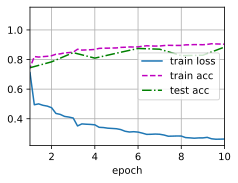

In [3]:
net = nn.Sequential(
    nn.Conv2d(1, 6, kernel_size=5), BatchNorm(6, num_dims=4), nn.Sigmoid(),
    nn.AvgPool2d(kernel_size=2, stride=2),
    nn.Conv2d(6, 16, kernel_size=5), BatchNorm(16, num_dims=4), nn.Sigmoid(),
    nn.AvgPool2d(kernel_size=2, stride=2), nn.Flatten(),
    nn.Linear(16*4*4, 120), BatchNorm(120, num_dims=2), nn.Sigmoid(),
    nn.Linear(120, 84), BatchNorm(84, num_dims=2), nn.Sigmoid(),
    nn.Linear(84, 10))

# 还是用之前的数据集跑一次。
lr, num_epochs, batch_size = 1.0, 10, 256
train_iter, test_iter = d2l.load_data_fashion_mnist(batch_size)
d2l.train_ch6(net, train_iter, test_iter, num_epochs, lr, d2l.try_gpu())

效果明显优于原LeNet（test acc ≈ 0.8）

下面看看学习到的两个新参数

In [4]:
# 查看第一个批量规范化层的gamma和beta参数
net[1].gamma.reshape((-1,)), net[1].beta.reshape((-1,))

(tensor([2.1127, 4.3578, 3.1422, 2.8722, 0.3546, 3.3551], device='cuda:0',
        grad_fn=<ViewBackward0>),
 tensor([-2.4491,  2.4852, -2.1938, -2.7475,  0.5931,  1.1823], device='cuda:0',
        grad_fn=<ViewBackward0>))

$\gamma$ 的值都不是1，这能说明批量规范化中拉伸参数的意义。

## 7.5.4 简明实现

利用深度学习框架，直接使用深度学习框架中定义的BatchNorm。高级API变体运行速度快得多，因为它的代码已编译为C++或CUDA，而我们的自定义代码由Python实现。

loss 0.265, train acc 0.903, test acc 0.808
57912.5 examples/sec on cuda:0


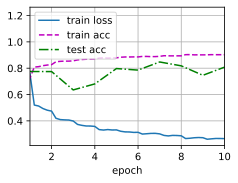

In [5]:
net = nn.Sequential(
    nn.Conv2d(1, 6, kernel_size=5), nn.BatchNorm2d(6), nn.Sigmoid(),
    nn.AvgPool2d(kernel_size=2, stride=2),
    nn.Conv2d(6, 16, kernel_size=5), nn.BatchNorm2d(16), nn.Sigmoid(),
    nn.AvgPool2d(kernel_size=2, stride=2), nn.Flatten(),
    nn.Linear(256, 120), nn.BatchNorm1d(120), nn.Sigmoid(),
    nn.Linear(120, 84), nn.BatchNorm1d(84), nn.Sigmoid(),
    nn.Linear(84, 10))

d2l.train_ch6(net, train_iter, test_iter, num_epochs, lr, d2l.try_gpu())

## 7.5.5 一些故事

在之前的学习中，我习惯于使用“直觉”，或者说希望使用一种直观的视角来理解各种技巧、操作。比如，这里的批量规范化可被认为是使优化更加平滑的技巧。*但，我们必须小心区分所谓的直觉和对我们观察到的现象的真实解释。我们甚至不知道简单的神经网络（多层感知机和传统的卷积神经网络）为什么如此有效。我们只是提出了一些看似合理的解释。*

在提出批量规范化的论文里，作者对其的解释是：*减少内部协变量偏移（internal covariate shift）*。即在训练过程中变量值的分布发生变化。但这种解释存在着问题：
1. 这种偏移与严格定义的协变量偏移（covariate shift）非常不同，所以这个名字用词不当； 
2. 这种解释只提供了一种不明确的直觉，但留下了一个有待后续挖掘的问题：为什么这项技术如此有效？ 

总之，我们要尽量的清楚地区分技术和直觉。批量规范化得到了广泛的使用，是一种不可或缺的方法，但对它的解释仍然有待探究。

## 7.5.6 小结、思考

1. 在模型训练过程中，批量规范化利用小批量的均值和标准差，不断调整神经网络的中间输出，使整个神经网络各层的中间输出值更加稳定。

2. 批量规范化在全连接层和卷积层的使用略有不同。

3. 批量规范化层和暂退层一样，在训练模式和预测模式下计算不同。

4. 批量规范化有许多有益的副作用，主要是正则化。另一方面，”减少内部协变量偏移“的原始动机似乎不是一个有效的解释。

**疑问**：
1. 既然偏移参数可学习，那么是否可以在先前的训练过程中删去偏置参数
2. 哪些层需要batchnorm？在不同位置应用有什么区别？是否所有层都运用更好？为什么？

**Ans**：
1. yes.
2. 
    1. 哪些层需要 BatchNorm？
    *   **需要加：** 网络的**隐藏层**（尤其是卷积层 Conv 和全连接层 Linear 之后）。
    *   **绝对不要加：** **输出层**（会破坏最终输出的绝对数值和物理意义）。
    *   **不建议加：** 处理可变长度序列的模型（如 Transformer/ViT，这类架构通常改用 **LayerNorm**）。

    2. 在不同位置应用有什么区别？
位置的选择主要取决于你使用的**激活函数**：
    *   **激活前（Linear $\rightarrow$ BN $\rightarrow$ 激活）：** 
        *   **适用：** Sigmoid 或 Tanh。
        *   **作用：** 把数据强行拉回到 $0$ 附近，精准落在这类函数梯度最陡峭的敏感区，防止**梯度消失**。
    *   **激活后（Linear $\rightarrow$ 激活 $\rightarrow$ BN）：**
        *   **适用：** ReLU 及其变体。
        *   **作用：** ReLU 会把负数变 $0$，导致输出均值严重偏离 $0$。在它后面加 BN，可以把这堆非对称数据重新“归一化”，给下一层喂入更标准、健康的输入。

    3. 是否所有层都运用更好？为什么？
**绝不是。** 无脑全覆盖会有三大负面后果：
        1.  **破坏特征表达：** 每一层都强行改变数据分布，会抹杀掉网络前层辛苦提取的、依赖于绝对数值大小的关键非线性特征。
        3.  **拖慢训练与吃显存：** BN 在反向传播时需要缓存大量的中间张量，所有层都加会无谓地消耗大量算力和显存。